In [31]:
import forgethreads as ft
import numpy as np



In [32]:

rng = np.random.default_rng()
ft.set_verbose(False)


In [33]:
# n= 100
# distribution = 0.7

# m_size = n ** 2 



# # Llenar segun distribucion

# m1= np.zeros(shape=(1,n,n))

# total_for_fill =  (n * (n-1)) / 2
# total_for_fill_pondered = total_for_fill * distribution

# ni = 0
# while(ni < total_for_fill_pondered):
#   o = rng.integers(0,n)
#   d = rng.integers(0,n)
#   if(m1[0,o,d]) == 0:
#     m1[0,o,d] = 1
#     m1[0,d,o] = 1
#     ni += 1



# m2 = m1.copy()
# paths,values, max_order = ft.maxmin(m1,m2,0.1,200,False)

In [53]:
def build_matrix(n, m, d, seed=None):
    rng = np.random.default_rng(seed)
    N = n + m
    M = np.zeros((N, N))

    A = rng.uniform(0, 0.5, size=(n, n))
    np.fill_diagonal(A, 1.0)
    M[:n, :n] = A

    D = rng.uniform(0, 0.5, size=(m, m))
    np.fill_diagonal(D, 1.0)
    M[n:, n:] = D

    M[:n, n:] = rng.uniform(0, 0.5, size=(n, m))

    # Máximo de aristas posibles por nodo (nodo en bloque n tiene más conexiones)
    max_degree   = (n - 1) + m
    total_possible = (n**2 - n) + (n * m) + (m**2 - m)

    # Objetivo: d * n aristas en total
    target_edges = int(round(d * n))
    target_edges = min(target_edges, total_possible)  # no puede superar el máximo

    # Celdas modificables con valor < 0.5
    mod = np.zeros((N, N), dtype=bool)
    mod[:n, :n] = True
    mod[:n, n:] = True
    mod[n:, n:] = True
    np.fill_diagonal(mod, False)

    current_edges = int(np.sum(M[mod] > 0.5))
    k_extra = max(0, target_edges - current_edges)

    candidates = np.argwhere(mod & (M < 0.5))
    k_extra = min(k_extra, len(candidates))

    if k_extra > 0:
        chosen = candidates[rng.choice(len(candidates), size=k_extra, replace=False)]
        M[chosen[:, 0], chosen[:, 1]] = rng.uniform(0.5, 1.0, size=k_extra)

    final = int(np.sum(M[mod] > 0.5))
    # print(f"  max_degree={max_degree}, total_posible={total_possible}")
    # print(f"  target={target_edges}, añadidas={k_extra}, final={final}, "
    #       f"densidad_real={final/n:.3f}")
    return M.reshape(1, N, N).astype(np.float16)

In [35]:
def create_by_distribution(n, avg_degree):
    """
    Grafo aleatorio dirigido [1, n, n] float16.
    avg_degree: grado promedio de salida por nodo (número de vecinos esperado).
    Aristas existentes: peso ~ U(0.55, 1.0).  No-aristas: peso = 0.
    """
    p = min(avg_degree / max(n - 1, 1), 1.0)
    mo = rng.uniform(0, 0.4, (n, n)).astype(np.float16)
    n_w = avg_degree * n
    
    for a in range(n_w):
      o = rng.int()
    mask = rng.random((n, n)) < p
    np.fill_diagonal(mask, False)
    weights = rng.uniform(0.55, 1.0, (n, n)).astype(np.float16)
    m1 = np.where(mask, weights, np.float16(0.0)).reshape(1, n, n)
    print(m1)
    return m1.astype(np.float16)

In [ ]:
def run_experimental(n, avg_degree,i):
    m1 = build_matrix(n,n,avg_degree,1111)
    m2 = m1.copy()
    paths, values, max_order = ft.maxmin(m1, m2, 0.5, 60)
    if i ==0:
      print(paths.to_numpy())
    return max_order

In [59]:
np.arange(1,3,step=0.001,dtype=np.float16) * 0.001

array([0.001   , 0.001001, 0.001002, ..., 0.00295 , 0.002953, 0.002954],
      shape=(2000,), dtype=float16)

In [62]:
ns = [400]
iterations = 1

proms_by_n = []
for n in ns:
    m = n
    max_d = float(n**2 - n + n*m + m**2 - m) / (n + m)

    # avg_degrees = np.array([0.1*max_d, 0.3*max_d, 0.5*max_d, 0.75*max_d], dtype=np.float16)
    
    avg_degrees = np.arange(2,3,step=0.001,dtype=np.float16) 
    print(avg_degrees)
    proms = []
    for deg in avg_degrees:
        acum = 0
        for i in range(iterations):
        
            acum += run_experimental(n, float(deg),i)
        proms.append(acum / iterations)
        print(f"deg={deg} : n={n} ", end="\t")
    print(f"\ncalculated averages for {n} nodes")
    proms_by_n.append(proms)

# p300 = np.load("proms_300n.npy")
# p400 = np.load("proms_400n.npy")
# p500 = np.load("proms_500n.npy")

# proms_by_n.append(p300[0]) E(eta_0) < b log(N), 
# proms_by_n.append(p400[0])
# proms_by_n.append(p500[0])

[2.    2.002 2.004 2.006 2.008 2.01  2.012 2.014 2.016 2.018 2.02  2.021
 2.023 2.025 2.027 2.03  2.031 2.033 2.035 2.037 2.04  2.041 2.043 2.045
 2.047 2.049 2.05  2.053 2.055 2.057 2.059 2.06  2.062 2.064 2.066 2.068
 2.07  2.072 2.074 2.076 2.078 2.08  2.082 2.084 2.086 2.088 2.09  2.092
 2.094 2.096 2.098 2.1   2.102 2.104 2.105 2.107 2.11  2.111 2.113 2.115
 2.117 2.12  2.121 2.123 2.125 2.127 2.129 2.13  2.133 2.135 2.137 2.139
 2.14  2.143 2.145 2.146 2.148 2.15  2.152 2.154 2.156 2.158 2.16  2.162
 2.164 2.166 2.168 2.17  2.172 2.174 2.176 2.178 2.18  2.182 2.184 2.186
 2.188 2.19  2.191 2.193 2.195 2.197 2.2   2.201 2.203 2.205 2.207 2.209
 2.21  2.213 2.215 2.217 2.219 2.22  2.223 2.225 2.227 2.229 2.23  2.232
 2.234 2.236 2.238 2.24  2.242 2.244 2.246 2.248 2.25  2.252 2.254 2.256
 2.258 2.26  2.262 2.264 2.266 2.268 2.27  2.271 2.273 2.275 2.277 2.28
 2.281 2.283 2.285 2.287 2.29  2.291 2.293 2.295 2.297 2.299 2.3   2.303
 2.305 2.307 2.309 2.31  2.312 2.314 2.316 2.318 2.3

In [ ]:
ns = [200]


In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_proms(ns, avg_degrees, proms_by_n):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        ax.plot(avg_degrees, proms_by_n[i], 'o-', label=f"N = {n}", 
                linewidth=2, markersize=5, color=color)

    ax.axvline(x=1.0,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(x=10.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xscale('log')
    ax.set_xticks(avg_degrees)
    ax.set_xticklabels([str(d) for d in avg_degrees], rotation=30, fontsize=9)
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel("Grado promedio (avg_degree)", fontsize=12)
    ax.set_ylabel("E[η₀] — orden máximo promedio", fontsize=12)
    ax.set_title("Orden máximo promedio vs densidad del grafo", fontsize=13)
    
    # Leyenda combinada: curva + ln(n)
    handles, labels = ax.get_legend_handles_labels()
    for i, n in enumerate(ns):
        color = colors[i % len(colors)]
        handles.append(plt.Line2D([0], [0], color=color, linestyle=':', linewidth=1.5, alpha=0.7))
    
    ax.legend(handles=handles, labels=labels, title="Nodos N", fontsize=10, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [40]:
np.save("all_degrees",proms_by_n)

/tmp/ipykernel_968/2933924214.py:30: UserWarning: Mismatched number of handles and labels: len(handles) = 2 len(labels) = 1
  ax.legend(handles=handles, labels=labels, title="Nodos N", fontsize=10, ncol=2)


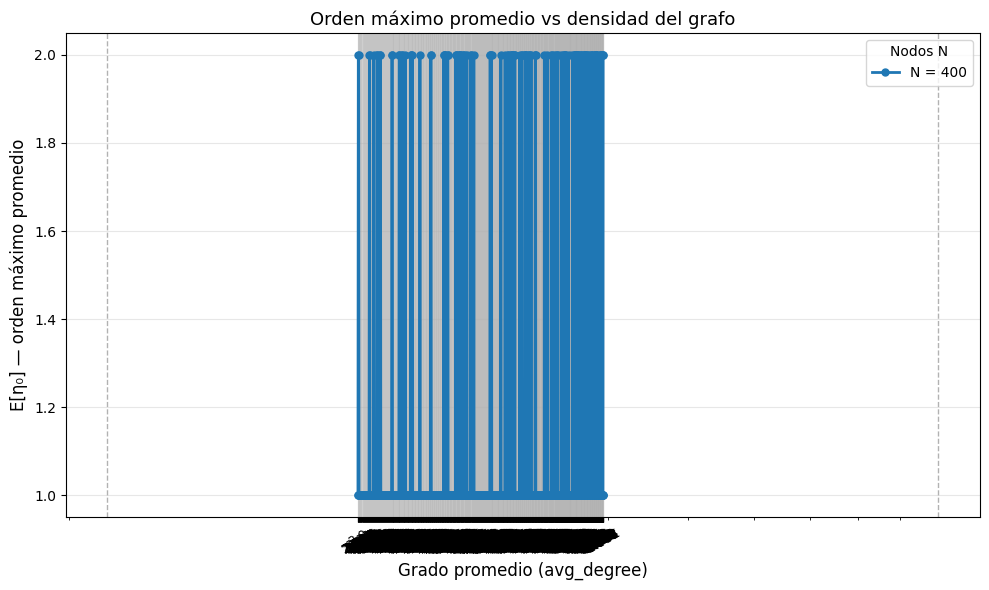

In [63]:
plot_proms(ns, avg_degrees, proms_by_n)